# **Taller Optimizacion 16 de Abril**


Disponibilidad de compuestos por semana:
*   Compuesto A: 120 Kg
*   Compuesto B: 80 Kg
*   Compuesto C: 150 Kg






In [2]:
from pulp import LpMaximize, LpProblem, LpVariable, value

# 1. Crear el problema
modelo = LpProblem(name="mezcla_fertilizantes", sense=LpMaximize)

# 2. Definir variables de decisión (no negativas por defecto)
x1 = LpVariable(name="Fertilizante_F1", lowBound=0)
x2 = LpVariable(name="Fertilizante_F2", lowBound=0)

# 3. Definir la función objetivo
modelo += 180 * x1 + 220 * x2, "Ganancia"

# 4. Añadir las restricciones
modelo += (3 * x1 + 4 * x2 <= 120, "Compuesto_A")
modelo += (2 * x1 + 1 * x2 <= 80,  "Compuesto_B")
modelo += (5 * x1 + 3 * x2 <= 150, "Compuesto_C")

modelo.solve()

print("=== Ejercicio 1: Fertilizantes ===")
print(f"Óptimo encontrado: x1 = {x1.varValue:.2f} ton, x2 = {x2.varValue:.2f} ton")
print(f"Ganancia máxima: ${value(modelo.objective):.2f}")

=== Ejercicio 1: Fertilizantes ===
Óptimo encontrado: x1 = 21.82 ton, x2 = 13.64 ton
Ganancia máxima: $6927.27


**Producción semanal de una fabrica**

In [3]:
# Ejercicio 2: Producción de sillas y mesas
# Sistema lineal discreto:
# S_{n+1} = 0.6*S_n + 0.2*M_n + 40
# M_{n+1} = 0.1*S_n + 0.5*M_n + 20
# S0 = 200, M0 = 80

import numpy as np
from scipy import linalg

# Parámetros y condición inicial
S0, M0 = 200, 80
coef = np.array([[0.6, 0.2], [0.1, 0.5]])
const = np.array([40, 20])

# Evolución temporal para las semanas 1 y 2
S, M = S0, M0
print("=== Ejercicio 2: Sillas y Mesas ===")
print(f"Semana 0: S = {S}, M = {M}")

for n in range(1, 3):
    S_next = coef[0,0]*S + coef[0,1]*M + const[0]
    M_next = coef[1,0]*S + coef[1,1]*M + const[1]
    S, M = S_next, M_next
    print(f"Semana {n}: S = {S:.2f}, M = {M:.2f}")

# Punto de equilibrio con scipy.linalg.solve
# Sistema: 0.4S - 0.2M = 40  y  -0.1S + 0.5M = 20
A_eq = np.array([[0.4, -0.2], [-0.1, 0.5]])
b_eq = np.array([40, 20])
equilibrio = linalg.solve(A_eq, b_eq)
print(f"\nPunto de equilibrio: S = {equilibrio[0]:.2f}, M = {equilibrio[1]:.2f}")

=== Ejercicio 2: Sillas y Mesas ===
Semana 0: S = 200, M = 80
Semana 1: S = 176.00, M = 80.00
Semana 2: S = 161.60, M = 77.60

Punto de equilibrio: S = 133.33, M = 66.67


**Modelo de Epidemia**

=== Ejercicio 3: Epidemia ===
Punto de equilibrio no trivial: I = 6666.67


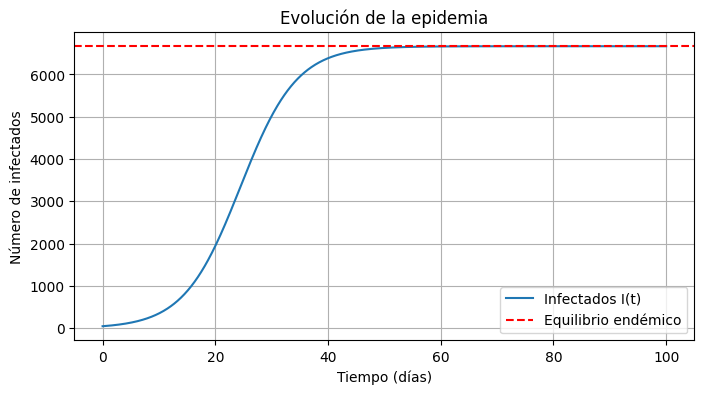

In [7]:
# Ejercicio 3: Modelo
# dI/dt = beta * (N - I) * I - gamma * I
# N = 10000, beta = 0.00003, gamma = 0.1, I(0)=50

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import fsolve

# Parámetros y condición inicial
beta, gamma, N = 0.00003, 0.1, 10000
I0 = 50

# Definición de la EDO
def sis_model(I, t, beta, gamma, N):
    return beta * (N - I) * I - gamma * I

# Puntos de equilibrio con fsolve
def eq_func(I):
    return beta * (N - I) * I - gamma * I

# Para evitar la solución trivial I=0, podemos buscar otras soluciones
I_guess = 5000
I_eq = fsolve(eq_func, I_guess)[0]

print("=== Ejercicio 3: Epidemia ===")
print(f"Punto de equilibrio no trivial: I = {I_eq:.2f}")

# Resolución numérica de la EDO
t = np.linspace(0, 100, 1000)
sol = odeint(sis_model, I0, t, args=(beta, gamma, N))

# Gráfico
plt.figure(figsize=(8,4))
plt.plot(t, sol, label='Infectados I(t)')
plt.axhline(y=I_eq, color='r', linestyle='--', label='Equilibrio endémico')
plt.xlabel('Tiempo (días)')
plt.ylabel('Número de infectados')
plt.title('Evolución de la epidemia')
plt.legend()
plt.grid(True)
plt.show()

**Modelo Logistico De pesca**

In [8]:
# Ejercicio 4: Modelo logístico de pesca
# P_{n+1} = P_n + r*P_n*(1 - P_n/K) - H
# r=0.4, K=1000, H=80, P0=400

import numpy as np
from scipy.optimize import fsolve

# Parámetros y condición inicial
r, K, H = 0.4, 1000, 80
P0 = 400

def next_pop(P):
    return P + r * P * (1 - P/K) - H

print("=== Ejercicio 4: Modelo logístico de pesca ===")

# Evolución para los primeros dos años
P = P0
print(f"Año 0: P = {P}")
for n in range(1, 3):
    P = next_pop(P)
    print(f"Año {n}: P = {P:.2f}")

# Puntos de equilibrio: r*P*(1-P/K) = H
def equilibrium_eq(P):
    return r * P * (1 - P/K) - H

# Buscar las dos raíces con diferentes valores iniciales
P_eq1 = fsolve(equilibrium_eq, 700)[0]   # Raíz alrededor de 700
P_eq2 = fsolve(equilibrium_eq, 200)[0]   # Raíz alrededor de 200

print(f"\nPuntos de equilibrio: P1 = {P_eq1:.2f}, P2 = {P_eq2:.2f}")
print("(El valor menor es inestable, el mayor es estable)")

# Simulación con población inicial baja (por debajo del umbral)
P0_bajo = 200
print(f"\nSimulación con P0 = {P0_bajo} (por debajo del equilibrio inestable):")
P = P0_bajo
for n in range(1, 11):
    P = next_pop(P)
    if P <= 0:
        print(f"Año {n}: población se extinguió (P <= 0)")
        break
    print(f"Año {n}: P = {P:.2f}")

=== Ejercicio 4: Modelo logístico de pesca ===
Año 0: P = 400
Año 1: P = 416.00
Año 2: P = 433.18

Puntos de equilibrio: P1 = 723.61, P2 = 276.39
(El valor menor es inestable, el mayor es estable)

Simulación con P0 = 200 (por debajo del equilibrio inestable):
Año 1: P = 184.00
Año 2: P = 164.06
Año 3: P = 138.91
Año 4: P = 106.76
Año 5: P = 64.91
Año 6: P = 9.18
Año 7: población se extinguió (P <= 0)
